## Ejercicios de histogramas y boxplots (Core)
##### Análisis de Distribución y Desviaciones Usando Histogramas y Boxplots

### 1.- Cargar y Explorar los Datos:

In [2]:

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('data/2019.csv')
display("df : ",df)

# mostrar los primeros 10 registros
print(" primeros 10 registros : \n",df.head(10))

# los ultimos 5 registros
print("ultimos 5 registros : \n",df.tail())

# informacion general del dataframe:
print("informacion general del dataframe : \n",df.info())

# informacion estadisticas del dataframe :
print("informacion estadisticas del dataframe : \n",df.describe())


'df : '

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035


 primeros 10 registros : 
    Overall rank Country or region  Score  GDP per capita  Social support  \
0             1           Finland  7.769           1.340           1.587   
1             2           Denmark  7.600           1.383           1.573   
2             3            Norway  7.554           1.488           1.582   
3             4           Iceland  7.494           1.380           1.624   
4             5       Netherlands  7.488           1.396           1.522   
5             6       Switzerland  7.480           1.452           1.526   
6             7            Sweden  7.343           1.387           1.487   
7             8       New Zealand  7.307           1.303           1.557   
8             9            Canada  7.278           1.365           1.505   
9            10           Austria  7.246           1.376           1.475   

   Healthy life expectancy  Freedom to make life choices  Generosity  \
0                    0.986                         0.596       0

In [ ]:

# - Identificar y abordar cualquier valor duplicado.
print("Duplicados totales:", df.duplicated().sum())

# no se encontraron datos duplicados


Duplicados totales: 0


In [ ]:
        # verificar datos nulos en el dataframe
print("\nDatos nulos por columna : \n")
print(df.isnull().sum())
# no se encontraron datos nulos




Datos nulos por columna : 

Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64


In [8]:
   # ver tipos de datos en columnas
print("tipos de datos : ",df.dtypes)

diccionario={
   'Overall rank'                  : 'int64',
   'Country or region'             : 'str',
   'Score'                         :  'float64',
   'GDP per capita'                : 'float64',
   'Social support'                : 'float64',
   'Healthy life expectancy'       : 'float64',
   'Freedom to make life choices'  : 'float64',
   'Generosity'                    : 'float64',
   'Perceptions of corruption'     : 'float64',
}

tipos de datos :  Overall rank                      int64
Country or region                object
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object


In [9]:
print("\nIdentificar y abordar cualquier inconsistencia en los valores categóricos\n")
for col in df.columns:
    valores_unicos = df[col].unique()
    print(f"• {col:20} -> {len(valores_unicos)} únicos")
    print(f"  Lista de Valores :   {valores_unicos}\n")



Identificar y abordar cualquier inconsistencia en los valores categóricos

• Overall rank         -> 156 únicos
  Lista de Valores :   [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156]

• Country or region    -> 156 únicos
  Lista de Valores :   ['Finland' 'Denmark' 'Norway' 'Iceland' 'Netherlands' 'Switzerland'
 'Sweden' 'New Zealand' 'Canada' 'Austria' 'Australia' 'Costa Rica'
 'Israel' 'Luxembourg' 'United Ki

##### RP:  no se encuentran inconsistencias en los valores categoricos


#### 2.- Crear Histogramas:

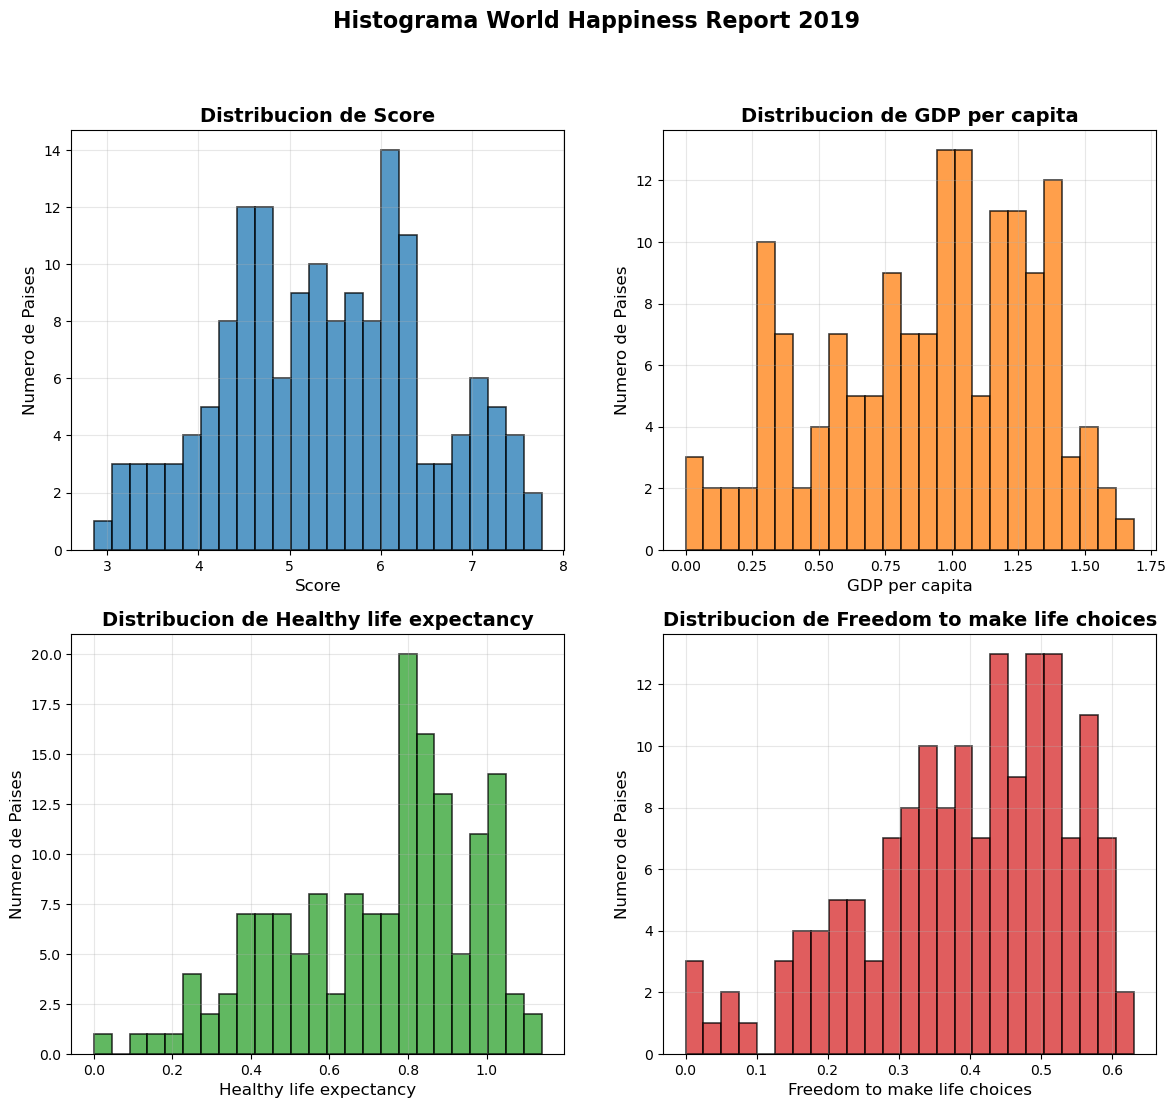

In [19]:
# Crea histogramas para las variables Score, GDP per capita, Healthy life expectancy y Freedom to make life choices.
# Personaliza los histogramas con colores, bordes y ajustes de transparencia.

# se realiza la carga de las variables en una lista de nombre variables
variables = ['Score', 'GDP per capita', 'Healthy life expectancy', 'Freedom to make life choices']

fig, axes = plt.subplots(2, 2, figsize=(14, 12)) # tamaños

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']   # Colores para los histogramas

for ax, var, color in zip(axes.flatten(), variables, colors): # for recorre lista Variables y construira los histogramas
    ax.hist(df[var], 
            bins=25,                    # cantidad de barras
            alpha=0.75,                 # Transparencia
            color=color,                # Colores cargados en la variable colors
            edgecolor='black',          # Bordes negros
            linewidth=1.2)              # bordes tipo grosor
    
    ax.set_title(f'Distribucion de {var}', fontsize=14, fontweight='bold')
    ax.set_xlabel(var, fontsize=12)
    ax.set_ylabel('Numero de Paises', fontsize=12)
    ax.grid(True, alpha=0.3)          

plt.suptitle('Histograma World Happiness Report 2019',
             fontsize=16, 
             fontweight='bold'
             )

#plt.tight_layout(rect=[0, 0, 1, 0.96])  # Ajuste para el suptitle
plt.show()   # o plt.savefig('personalized_histograms.png')

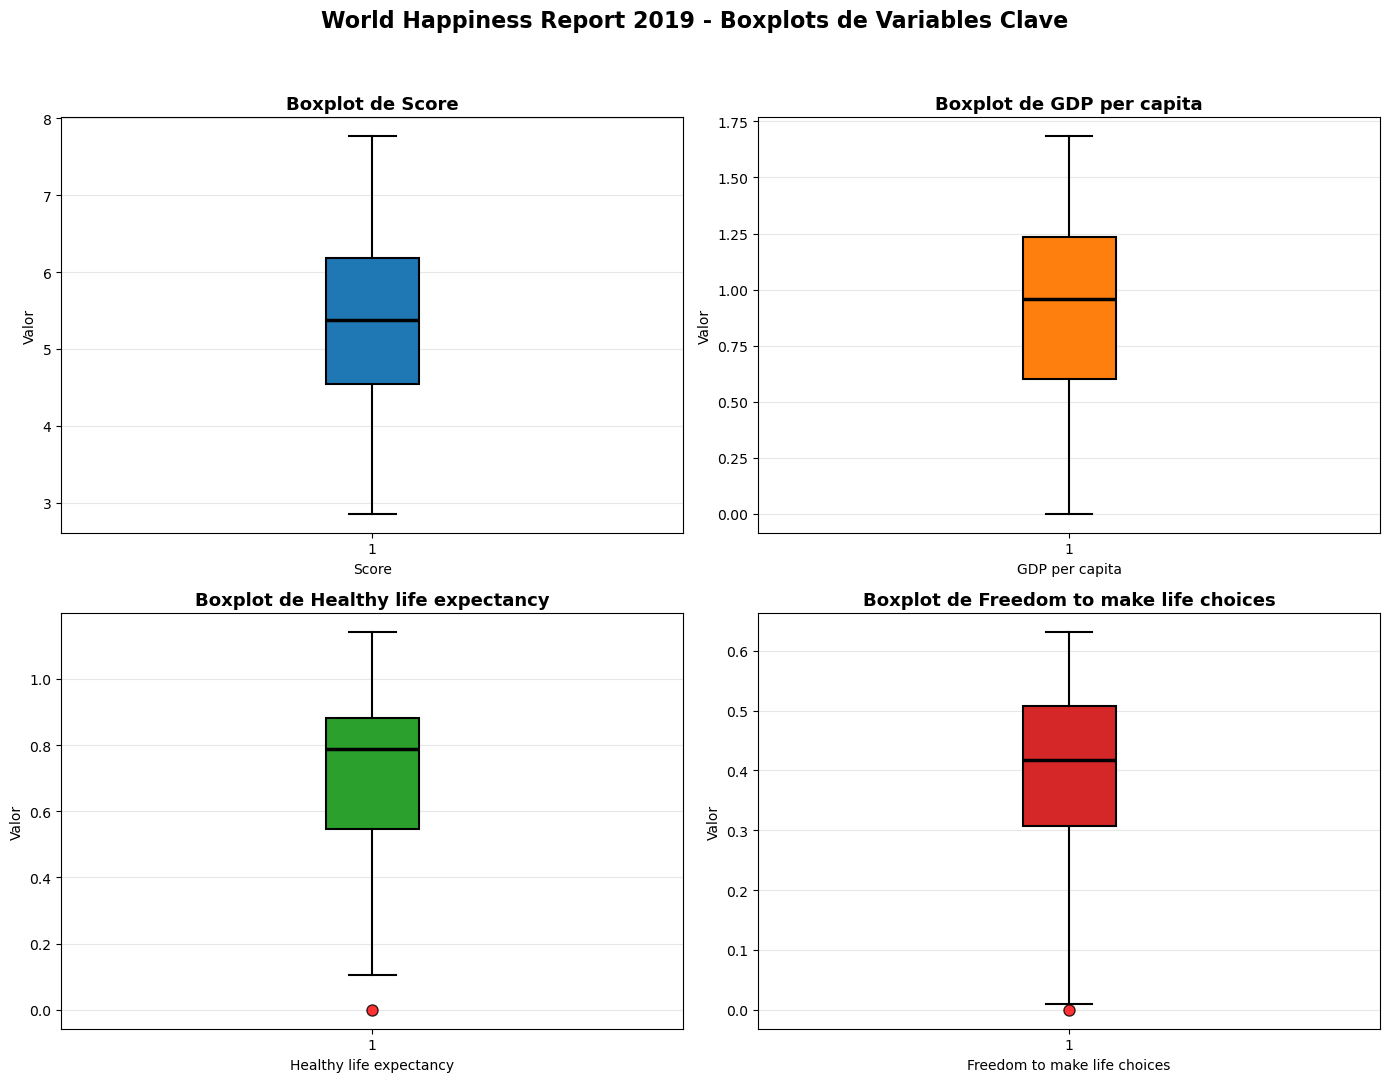

In [ ]:
variables = ['Score', 'GDP per capita', 'Healthy life expectancy', 'Freedom to make life choices']

# Crea figuras de 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 11))


colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Colores para los histogramas

for ax, var, color in zip(axes.flatten(), variables, colors):
    bp = ax.boxplot(df[var], 
                    patch_artist=True,          
                    boxprops=dict(facecolor=color, color='black', linewidth=1.5),
                    medianprops=dict(color='black', linewidth=2.5),
                    whiskerprops=dict(color='black', linewidth=1.5),
                    capprops=dict(color='black', linewidth=1.5),
                    flierprops=dict(marker='o', 
                                    markerfacecolor='red', 
                                    markersize=8, 
                                    alpha=0.8))
    
    ax.set_title(f'Boxplot de {var}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Valor')
    ax.set_xlabel(f'{var}')

    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Boxplots World Happiness Report 2019', 
             fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Interpretacion de los histogramas

##### - Distribución del Puntaje de Felicidad:
##### histograma : se obserban paises con un nivel de felicidad muy alto , tambien la baja de felicidad se concentra en los extremos , la distribucion no es normal lo que indica que la felicidad de los paises es polarizada
##### boxplots : se aprecia que los rangos de la felicidad se encuentran situados en los rangos medios-altos. y los paises se encuentra mas sobre la media.

##### - Distribución del PIB per Cápita:
#####  histograma :  se observa  en este grafico la separacion de paises ricos y pobres, donde los paises que con mas ganancia per capita estan concentrados en 0.9 y 1.4. esto puede influir en la felicidad de los paises

##### boxplots : se observa una gran cantidad paises con un ingreso per capita alto pero tambien muchos con un ingreso bajo 

##### - Distribución de la Expectativa de Vida Saludable:
##### 
##### histograma : se ve que una gran parte de los paises tiene una esperanza de vida superior a 0.7 y se encuentra pocos paises bajo los 0.4 que se concidera bueno.

##### boxplots : se observa una gran cantidad de paises con una excelente calidad de vida y existe un pequeño grupo con niveles de esperanza de vida malos

##### - Distribución de la Libertad para Tomar Decisiones de Vida:
##### 
##### histograma :se observa que la concentracion de la toma de decisiciones se concentra entre 0.3 y 0.6 lo que habla de libertades altas en el mundo

##### boxplots : en la mayoria se observa libertades altas aunque tambien se registras libertades bajas 